## 0. Environment & Imports

Target: **Windows + RTX 5060 Laptop (CUDA)**. Requires `ultralytics` (YOLO26) and, for Step 7,
`onnxruntime`. Uncomment to install.

In [1]:
# !pip install ultralytics onnxruntime pydicom pylibjpeg pylibjpeg-libjpeg pylibjpeg-openjpeg \
# !             opencv-python-headless scikit-image scikit-learn matplotlib seaborn pandas

import os, glob, re, random, warnings, json, math
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns
from skimage.feature import graycomatrix, graycoprops
from ultralytics import YOLO

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")
random.seed(42); np.random.seed(42)
print("OpenCV:", cv2.__version__)


OpenCV: 4.13.0


## 2. Configuration & Paths

All outputs land in a single organized tree (`OUT_DIR`), and a small `savefig()` helper writes every
figure into `figures/` so each cell leaves a saved artifact behind.

In [2]:
# -------------------- Data paths (multi-view: AP frontal + LA lateral) --------------------
BUU_ROOT = "./BUU-LSPINE-2000"
VIEWS    = ["AP", "LA"]                    # views to train on: ["AP"], ["LA"], or both
def view_dirs(view):
    base = os.path.join(BUU_ROOT, view)
    return os.path.join(base, "images"), os.path.join(base, "labels")

TEST_DCM_DIR  = "./dataset-dcm/test/gather"
TEST_MASK_DIR = "./dataset-dcm/test/gather_mask/SegmentationClass"   # L4 ground-truth (PNG, AP)

# -------------------- Output tree --------------------
OUT_DIR     = "./l4_v7_output"
FIG_DIR     = os.path.join(OUT_DIR, "figures")        # every cell's visualization
SEG_DIR     = os.path.join(OUT_DIR, "segmentation")   # per-image overlays + masks
METRICS_DIR = os.path.join(OUT_DIR, "metrics")        # CSVs
EXPORT_DIR  = os.path.join(OUT_DIR, "export")         # ONNX model for the web project
REPORT_DIR  = os.path.join(OUT_DIR, "reports")        # v16: per-study clinical report card + JSON
for _d in (OUT_DIR, FIG_DIR, SEG_DIR, METRICS_DIR, EXPORT_DIR, REPORT_DIR):
    os.makedirs(_d, exist_ok=True)

def savefig(fig, name, dpi=150):
    '''Save a figure into FIG_DIR and return its path (call right before plt.show()).'''
    path = os.path.join(FIG_DIR, name)
    fig.savefig(path, dpi=dpi, bbox_inches="tight")
    return path

# -------------------- Model / Training --------------------
YOLO_BASE      = "yolo26m-seg.pt"          # YOLO26 medium SEG backbone (fallback: -s / -n)
# IMPORTANT: pass an ABSOLUTE project path. In ultralytics 8.4.x, a *relative* `project` is
# re-nested under RUNS_DIR/<task>/, so project="runs/segment/ap_seg" would be written to
# runs/segment/runs/segment/ap_seg/... An absolute path is used verbatim.
YOLO_PROJECT   = os.path.abspath(os.path.join("runs", "segment", "ap_seg"))
YOLO_NAME      = "l1_l5_yolo26m_" + "_".join(v.lower() for v in VIEWS)  # e.g. l1_l5_yolo26m_ap_la
YOLO_WEIGHTS   = os.path.join(YOLO_PROJECT, YOLO_NAME, "weights", "best.pt")
YOLO_DATA_ROOT = os.path.abspath("yolo_ap_la_seg")     # converted multi-view YOLO-seg dataset
CONF           = 0.25

# Training controls. The 42 DICOMs are TEST-ONLY.
RETRAIN   = False     # True -> force retrain from YOLO_BASE; else reuse best.pt if present
EPOCHS    = 100
IMGSZ     = 640
VAL_RATIO = 0.15
SEED      = 42
# ---- Training speed / hardware (v15) ----
BATCH   = 8                  # EXPLICIT integer batch. Do NOT use the float form here.
                             #   The old BATCH=0.85 (AutoBatch "use 85% of VRAM") mis-estimated to
                             #   batch=2 on this RTX 5060 + torch-nightly, leaving the GPU half idle.
                             #
                             #   Benchmarked on this box (yolo26m-seg, imgsz=640, cache="ram"):
                             #     batch  img/s   peak VRAM
                             #       2    12.4      2.3 G   <- what 0.85 actually picked
                             #       8    18.6      6.4 G   <- 1.5x faster; the sweet spot
                             #      10     9.5      7.3 G   <- SLOWER: too close to the 8151 MiB card,
                             #                                Windows WDDM spills to shared system
                             #                                memory instead of raising CUDA OOM.
                             #   So 8 is the ceiling, not a floor -- raising it silently backfires.
                             #   Close other GPU apps (e.g. LM Studio) before training; they steal VRAM.
WORKERS = 8                  # dataloader workers. If training HANGS at start on Windows, set 0.
                             #   Swept 4/8/12 at batch=8: 19.2 / 18.6 / 18.8 img/s -- the loader is
                             #   not the bottleneck (GPU-bound), so there is nothing to win here.
CACHE   = "ram"              # cache decoded images once: "ram" | "disk" | False.
                             #   Measured ~0.3 GB per 340 images -> ~3 GB for the 3400-image train
                             #   split. Cheap; keep it. (The 88% system-RAM reading seen during an
                             #   earlier run came from other processes, not this cache.)
FORCE_REBUILD_DATA = False   # rebuild the YOLO-seg dataset even if it already exists on disk

random.seed(SEED); np.random.seed(SEED)

# -------------------- Task --------------------
CLASS_NAMES = ["L1", "L2", "L3", "L4", "L5"]
L4_IDX      = CLASS_NAMES.index("L4")     # = 3
GLCM_LEVELS = 32
ROI_SHRINK  = 0.85                        # legacy centroid shrink (fallback only)

# ======================= v16 — clinician-facing measurement config =======================
# ---- (a) Detector response: how a pixel value relates to X-ray attenuation ----
#   "auto"   -> read DICOM (0028,1040) PixelIntensityRelationship: LIN -> "linear", LOG -> "log"
#   "log"    -> pixel is already affine in attenuation (most processed CR/DX)  => A = I
#   "linear" -> pixel is proportional to transmitted intensity                 => A = -ln(1 - I)
DETECTOR_RESPONSE = "auto"
DEFAULT_RESPONSE  = "log"     # used when the DICOM tag is absent (JPG/PNG, anonymised headers)

# ---- (b) Trabecular ROI geometry ----
ERODE_FRAC    = 0.10          # erosion kernel = 10% of vertebral body height (cortical rim)
ENDPLATE_FRAC = 0.18          # strip 18% off the top and bottom (endplates)

# ---- (c) Microarchitecture ----
VARIO_MAX_LAG = 8             # lags 1..8 px for the TBS-like log-log variogram slope
FRACTAL_BLOCK = 31            # adaptive-threshold window for box-counting fractal dimension

# ---- (d) Quality-control gate (a doctor must know when NOT to trust a number) ----
QC_MIN_ROI_PX      = 300      # trabecular ROI smaller than this -> FAIL
QC_MAX_SATURATED   = 0.02     # >2% clipped (0 or 1) pixels in the ROI -> WARN
QC_MIN_SOFT_MARGIN = 0.02     # A_soft - A_air below this -> soft-tissue reference unusable -> FAIL
QC_MIN_VERT        = 3        # fewer than 3 lumbar vertebrae detected -> WARN

# ---- (e) Composite Bone Health Index: feature -> weight (renormalized over available features) ----
BHI_WEIGHTS = {"bar": 0.50, "vario_slope": 0.20, "fractal_dim": 0.15,
               "glcm_homogeneity": 0.075, "glcm_entropy": 0.075}

# ---- (f) Proxy categories on the cohort z of BAR. NOT DXA T-scores. ----
CAT_LOW, CAT_VERYLOW = -1.0, -2.5           # WHO-style cut-points, applied to a cohort z-score
CAT_LABELS = {"normal":   "Within reference range",
              "low":      "Low (osteopenia-like)",
              "very_low": "Very low (osteoporosis-like)"}

# ---- (g) Precision / Least Significant Change (ISCD: LSC = 2.77 x RMS-CV%) ----
LSC_REPEATS   = 5             # perturbed re-measurements per study
LSC_N_STUDIES = 12            # studies used for the precision experiment (keep small: it re-runs YOLO)
LSC_JITTER    = {"deg": 2.0, "shift_frac": 0.01, "scale": 0.02}   # +/- rotation, translation, scale

REFERENCE_JSON = os.path.join(METRICS_DIR, "bmd_reference.json")

print(f"Backbone     : {YOLO_BASE}")
print(f"Views        : {VIEWS}")
print(f"Weights path : {YOLO_WEIGHTS}")
print("Status       :", "found (reuse)" if os.path.exists(YOLO_WEIGHTS)
      else "absent -> Step 2 will train on BUU-LSPINE-2000")
print(f"Output tree  : {OUT_DIR}/  (figures, segmentation, metrics, export, reports)")
print(f"v16 measure  : response={DETECTOR_RESPONSE!r} (default {DEFAULT_RESPONSE!r}) | "
      f"BHI weights={BHI_WEIGHTS} | categories at z={CAT_LOW}/{CAT_VERYLOW}")


Backbone     : yolo26m-seg.pt
Views        : ['AP', 'LA']
Weights path : C:\Users\csm02\Desktop\edward\bmd\src\BMD\model\runs\segment\ap_seg\l1_l5_yolo26m_ap_la\weights\best.pt
Status       : found (reuse)
Output tree  : ./l4_v7_output/  (figures, segmentation, metrics, export, reports)
v16 measure  : response='auto' (default 'log') | BHI weights={'bar': 0.5, 'vario_slope': 0.2, 'fractal_dim': 0.15, 'glcm_homogeneity': 0.075, 'glcm_entropy': 0.075} | categories at z=-1.0/-2.5


### Image loaders (JPG / DICOM)

Each loader returns **two views** of one X-ray:
- `rgb_uint8` — a display-normalized 3-channel image **fed to YOLO** (bright bone, percentile-windowed;
  MONOCHROME1 DICOMs are inverted).
- `gray_lin` — a **linear** min–max normalized grayscale used for **BMD/GLCM** (no CLAHE, so the
  density meaning is preserved).

In [3]:
# ---- DICOM file discovery: some cohorts use ".dicom" instead of ".dcm" ----
# (e.g. the lateral dataset ships 176 x ".dicom"). Extension is only a naming
# convention, not part of the DICOM standard, so we accept both everywhere.
DICOM_EXTS = (".dcm", ".dicom")

def is_dicom(path):
    """True if the path looks like a DICOM file (.dcm or .dicom, case-insensitive)."""
    return os.path.splitext(str(path))[1].lower() in DICOM_EXTS

def dicom_files(dirpath):
    """Sorted DICOM files in a directory, regardless of which extension is used."""
    out = []
    for ext in DICOM_EXTS:
        out += glob.glob(os.path.join(dirpath, "*" + ext))
        out += glob.glob(os.path.join(dirpath, "*" + ext.upper()))
    return sorted(set(out))

def load_xray(path):
    '''Return (rgb_uint8 for YOLO, gray_lin float[0,1] for BMD/GLCM, H, W).
       gray_lin uses a robust 0.5/99.5-percentile window (v13), so a single hot/dead
       pixel no longer skews the normalization. Bone is bright in both outputs.'''
    if is_dicom(path):
        import pydicom
        ds  = pydicom.dcmread(path)
        raw = ds.pixel_array.astype(np.float32)
        raw = raw * float(getattr(ds, "RescaleSlope", 1.0)) + float(getattr(ds, "RescaleIntercept", 0.0))
        if str(getattr(ds, "PhotometricInterpretation", "")).upper() == "MONOCHROME1":
            raw = raw.max() - raw                       # bright bone, linear
        lo, hi = np.percentile(raw, 0.5), np.percentile(raw, 99.5)
        if hi <= lo:
            lo, hi = raw.min(), raw.max() + 1e-6
        gray_lin = np.clip((raw - lo) / (hi - lo), 0, 1).astype(np.float32)
        # Some DICOMs hand back (H, W, 1); every downstream consumer (masks, GLCM,
        # boolean indexing such as img_norm[roi > 0]) assumes a plain 2-D array, so
        # collapse the trailing singleton here rather than defending in each caller.
        gray_lin = np.squeeze(gray_lin)
        rgb = cv2.cvtColor((gray_lin * 255).astype(np.uint8), cv2.COLOR_GRAY2RGB)
        return rgb, gray_lin, gray_lin.shape[0], gray_lin.shape[1]
    g = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    if g is None:
        raise FileNotFoundError(path)
    rgb = cv2.cvtColor(g, cv2.COLOR_GRAY2RGB)
    lo, hi = np.percentile(g, 0.5), np.percentile(g, 99.5)
    if hi <= lo:
        lo, hi = float(g.min()), float(g.max()) + 1e-6
    gray_lin = np.squeeze(np.clip((g.astype(np.float32) - lo) / (hi - lo), 0, 1)).astype(np.float32)
    return rgb, gray_lin, gray_lin.shape[0], gray_lin.shape[1]

# ---- v16: read the detector response + pixel spacing from the DICOM header (no pixel decode) ----
_META_CACHE = {}

def xray_meta(path):
    '''Header-only metadata that the *measurement* depends on.

       response          : "log" | "linear"  -> which attenuation map to use (see Section 1.1)
       response_source   : where that decision came from (audit trail)
       pixel_spacing_mm  : physical pixel size, when the header provides it
    '''
    if path in _META_CACHE:
        return _META_CACHE[path]
    meta = {"response": DEFAULT_RESPONSE, "response_source": "default (no DICOM tag)",
            "pixel_spacing_mm": None}
    if is_dicom(path):
        try:
            import pydicom
            ds = pydicom.dcmread(path, stop_before_pixels=True)
            pir = str(getattr(ds, "PixelIntensityRelationship", "")).strip().upper()
            if pir in ("LIN", "LOG"):
                meta["response"] = "linear" if pir == "LIN" else "log"
                meta["response_source"] = f"DICOM PixelIntensityRelationship={pir}"
            ps = getattr(ds, "ImagerPixelSpacing", None) or getattr(ds, "PixelSpacing", None)
            if ps is not None:
                meta["pixel_spacing_mm"] = float(ps[0])
        except Exception as e:                      # unreadable header -> fall back, but say so
            meta["response_source"] = f"default (header unreadable: {type(e).__name__})"
    if DETECTOR_RESPONSE != "auto":                 # explicit config always wins
        meta["response"] = DETECTOR_RESPONSE
        meta["response_source"] = f"config override DETECTOR_RESPONSE={DETECTOR_RESPONSE!r}"
    _META_CACHE[path] = meta
    return meta

def list_pairs(views=VIEWS):
    '''Images (across the given views) that have a matching label file.'''
    pairs = []
    for view in views:
        img_dir, lbl_dir = view_dirs(view)
        for lp in sorted(glob.glob(os.path.join(lbl_dir, "*"))):
            stem = os.path.splitext(os.path.basename(lp))[0]
            for ext in (".jpg", ".jpeg", ".png"):
                ip = os.path.join(img_dir, stem + ext)
                if os.path.exists(ip):
                    pairs.append(ip); break
    return pairs

buu_by_view    = {v: list_pairs([v]) for v in VIEWS}     # per-view samples (for visualization)
buu_imgs       = [p for v in VIEWS for p in buu_by_view[v]]
test_dcm_files = dicom_files(TEST_DCM_DIR)
eval_items     = [p for p in test_dcm_files
                  if os.path.exists(os.path.join(TEST_MASK_DIR,
                     os.path.splitext(os.path.basename(p))[0] + ".png"))]
print("BUU images per view:", {v: len(buu_by_view[v]) for v in VIEWS},
      f"| total {len(buu_imgs)}")
print(f"DICOM test: {len(test_dcm_files)} ({len(eval_items)} with L4 ground truth)")
if test_dcm_files:
    _m = xray_meta(test_dcm_files[0])
    print(f"Detector response of {os.path.basename(test_dcm_files[0])}: "
          f"{_m['response']!r}  <- {_m['response_source']}")


BUU images per view: {'AP': 2000, 'LA': 2000} | total 4000
DICOM test: 42 (42 with L4 ground truth)
Detector response of 1.2.826.0.1.3680043.8.498.10406657579016312201439626146133412368-c.dcm: 'log'  <- default (no DICOM tag)


In [4]:
# --- v18 cross-check harness: load the ALREADY-TRAINED weights directly, skip retrain/val ---
assert os.path.exists(YOLO_WEIGHTS), YOLO_WEIGHTS
seg = YOLO(YOLO_WEIGHTS)
print('Loaded YOLO26-seg:', YOLO_WEIGHTS)

Loaded YOLO26-seg: C:\Users\csm02\Desktop\edward\bmd\src\BMD\model\runs\segment\ap_seg\l1_l5_yolo26m_ap_la\weights\best.pt


### L4 extraction & visualization

The trained model detects L1–L5 as instances. The L4 mask is chosen by **class** when available, else
by the **4th-from-top** rule (vertebrae ordered by vertical centroid). A single `yolo_l4()` helper
returns the selected L4 mask, the status, **all** instance masks, and the raw result — every later
step reuses it (no duplicated inference helpers).

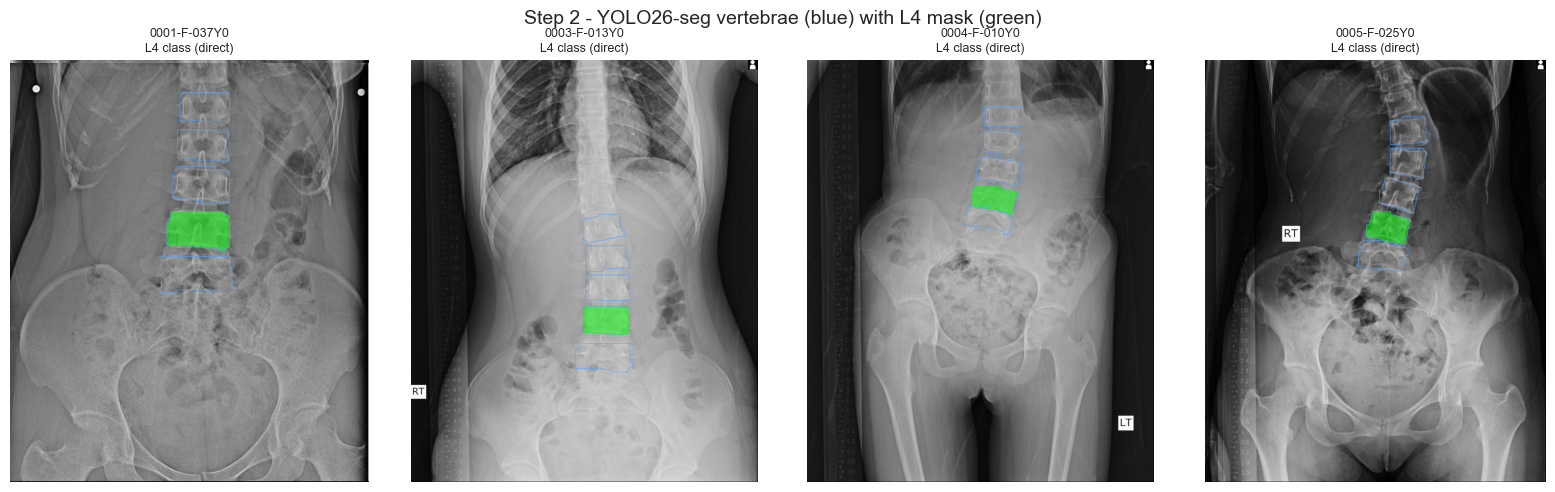

In [5]:
def poly_to_mask(poly_xy, H, W, shrink=1.0):
    poly = np.asarray(poly_xy, np.float32)
    if shrink != 1.0 and len(poly):
        ctr = poly.mean(0); poly = ctr + shrink * (poly - ctr)
    m = np.zeros((H, W), np.uint8)
    if len(poly):
        cv2.fillPoly(m, [poly.astype(np.int32)], 1)
    return m

def pick_l4_index(boxes_xyxy, classes, confs):
    '''Choose the L4 instance: direct class, else 4th vertebra from the top (fallback).'''
    if len(boxes_xyxy) == 0:
        return None, "no detection"
    idx = [i for i, c in enumerate(classes) if c == L4_IDX]
    if idx:
        return max(idx, key=lambda i: confs[i]), "L4 class (direct)"
    order = sorted(range(len(boxes_xyxy)), key=lambda i: (boxes_xyxy[i][1] + boxes_xyxy[i][3]) / 2)
    if len(order) >= 4:
        return order[3], "4th-from-top (fallback)"
    return None, f"only {len(boxes_xyxy)} vertebrae"

def yolo_l4(rgb, conf=CONF, shrink=1.0):
    '''Run YOLO once. Return (l4_mask|None, status, all_instance_masks, result).'''
    r = seg.predict(rgb, conf=conf, verbose=False)[0]
    H, W = rgb.shape[:2]
    if r.masks is None or len(r.boxes) == 0:
        return None, "no detection", [], r
    boxes   = r.boxes.xyxy.cpu().numpy()
    classes = r.boxes.cls.cpu().numpy().astype(int)
    confs   = r.boxes.conf.cpu().numpy()
    inst = [poly_to_mask(r.masks.xy[i], H, W, shrink) for i in range(len(r.masks.xy))]
    i, status = pick_l4_index(boxes, classes, confs)
    return (inst[i] if i is not None else None), status, inst, r

# ---- Visualization: YOLO segmentation with L4 highlighted ----
fig, axes = plt.subplots(1, 4, figsize=(16, 5))
for k, p in enumerate(buu_imgs[:4]):
    rgb, _, H, W = load_xray(p)
    m, status, inst, r = yolo_l4(rgb)
    vis = rgb.copy()
    if r.masks is not None:
        for poly in r.masks.xy:
            cv2.polylines(vis, [poly.astype(np.int32)], True, (80, 160, 255), 2)
    if m is not None:
        vis[m > 0] = (0.5 * vis[m > 0] + 0.5 * np.array([0, 255, 0])).astype(np.uint8)
    axes[k].imshow(vis); axes[k].set_title(f"{os.path.basename(p)[:12]}\n{status}", fontsize=9)
    axes[k].axis("off")
fig.suptitle("Step 2 - YOLO26-seg vertebrae (blue) with L4 mask (green)", fontsize=14)
plt.tight_layout(); savefig(fig, "step2_l4_extraction.png"); plt.show()

## Step 3 — The Measurement Core

Five short cells, in the order a clinician would ask about them:

| cell | question it answers |
|---|---|
| **3a** | *Where exactly do you measure?* — trabecular ROI, soft-tissue reference, air reference |
| **3b** | *What number do you report?* — the attenuation domain and **BAR**, plus microarchitecture |
| **3c** | *How do I run it, and can I trust this one?* — `measure_l4()` and the **QC gate** |
| **3d** | *What does the number mean?* — cohort reference, z-score, **BHI**, category, plain English |
| **3e** | *Is a change between visits real?* — precision and **Least Significant Change** |


In [6]:
# ===== Step 3a — WHERE we measure: trabecular ROI, soft-tissue reference, air reference =====

def shrink_mask(mask, shrink=ROI_SHRINK):
    """Scale the mask toward its centroid (kept as a robust fallback for trabecular_roi)."""
    if shrink >= 1.0:
        return mask
    ys, xs = np.where(mask > 0)
    if len(xs) == 0:
        return mask
    cx, cy = xs.mean(), ys.mean()
    out = np.zeros_like(mask)
    nx = np.clip((cx + shrink * (xs - cx)).astype(int), 0, mask.shape[1] - 1)
    ny = np.clip((cy + shrink * (ys - cy)).astype(int), 0, mask.shape[0] - 1)
    out[ny, nx] = 1
    return cv2.morphologyEx(out, cv2.MORPH_CLOSE, np.ones((3, 3), np.uint8))

def trabecular_roi(mask, erode_frac=ERODE_FRAC, endplate_frac=ENDPLATE_FRAC):
    """Central *trabecular* ROI: (1) erode away the dense cortical rim, then (2) drop the
       superior & inferior endplate bands (the brightest, most-contaminated rows). What
       remains is cancellous bone: no cortex, no endplate, no projection edge.
       Falls back to shrink_mask if the erosion is degenerate."""
    m = (mask > 0).astype(np.uint8)
    ys, xs = np.where(m)
    if len(xs) == 0:
        return mask
    y0, y1 = ys.min(), ys.max(); h = y1 - y0 + 1
    k = max(3, int(round(erode_frac * h)))
    er = cv2.erode(m, np.ones((k, k), np.uint8))
    cut = int(round(endplate_frac * h))                  # strip top & bottom endplate bands
    er[:y0 + cut] = 0
    er[y1 - cut + 1:] = 0
    if er.sum() < 10:                                    # too aggressive -> safe fallback
        return shrink_mask(mask)
    return er

# ---------------------------------------------------------------------------
# v16: the attenuation domain. A radiograph pixel is not a density -- the map from pixel to
# attenuation depends on the detector response (Section 1.1).
#   "log"    : the stored value is already affine in mu*t  ->  A = I
#   "linear" : the stored value tracks transmitted intensity; with bone bright, transmission
#              is (1 - I), so Beer-Lambert gives A = -ln(1 - I).
# Both are monotone increasing in attenuation, so bright still means dense.
# ---------------------------------------------------------------------------
def to_attenuation(gray, response=None):
    """Map a robustly-windowed [0,1] bright-bone image into an attenuation-proportional domain."""
    response = response or DEFAULT_RESPONSE
    if response == "log":
        return np.asarray(gray, np.float32)
    if response == "linear":
        g = np.clip(np.asarray(gray, np.float32), 0.0, 1.0 - 1e-4)
        return (-np.log1p(-g)).astype(np.float32)        # -ln(1 - g), numerically stable
    raise ValueError(f"unknown detector response {response!r} (expected 'log' or 'linear')")

def air_reference(gray):
    """Direct-exposure (unattenuated) background level, in *gray* units.

       Otsu splits body from background; we take the 25th percentile of the background so
       collimation borders and scattered soft tissue cannot pull the estimate up. Falls back
       to the 1st percentile when the field is tightly collimated (almost no visible air)."""
    u8 = (np.clip(gray, 0, 1) * 255).astype(np.uint8)
    thr, _ = cv2.threshold(u8, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    bg = gray[u8 < thr]
    if bg.size < 0.005 * gray.size:
        return float(np.percentile(gray, 1))
    return float(np.percentile(bg, 25))

SOFT_TISSUE_PCT = 25   # lower-quantile anchor for the soft-tissue reference (see below)

def soft_tissue_ref(img_norm, full_mask, exclude=None):
    """Median intensity of the paraspinal soft tissue just lateral to the vertebra -- the
       patient's own internal reference for BAR's denominator.

       Sampled left & right at mid-height (away from endplates); v17.1 keeps only the
       LOWER-median side so a lateral view cannot sample the posterior elements.
       v16 hardening:
         * every OTHER detected vertebra is removed via `exclude` (no adjacent bone leaks in),
         * the band is trimmed to its 20-80% core, so collimation air (dark) and residual
           bone / bowel gas (bright) cannot drag the median.
       Returns None when no usable band exists (-> BAR is reported as None, and QC fails)."""
    ys, xs = np.where(full_mask > 0)
    if len(xs) == 0:
        return None
    y0, y1, x0, x1 = ys.min(), ys.max(), xs.min(), xs.max()
    Hh, Ww = img_norm.shape[:2]
    h, w = y1 - y0 + 1, x1 - x0 + 1
    ym0, ym1 = y0 + h // 4, y1 - h // 4
    gap = max(3, int(0.15 * w)); wid = max(5, int(0.5 * w))
    band = np.zeros((Hh, Ww), bool)
    band[ym0:ym1, max(0, x0 - gap - wid):max(0, x0 - gap)] = True
    band[ym0:ym1, min(Ww, x1 + gap):min(Ww, x1 + gap + wid)] = True
    band &= (full_mask == 0)
    if exclude is not None:
        band &= (exclude == 0)

    v = img_norm[band]
    if v.size < 50:
        return None

    # ---- v17.2: lower-quantile estimator (replaces the band-median heuristics) ----
    # Whatever contaminates this band -- posterior elements on a lateral view, ribs,
    # ilium, transverse processes -- can only ADD attenuation. There is no
    # contamination that subtracts. The bias is therefore strictly one-sided, and a
    # MEDIAN is the wrong statistic: it assumes contamination stays below 50%, which
    # lateral projections violate. Measured consequence: A_soft came out ABOVE
    # A_trabecular on 2 of 25 lateral studies, i.e. bone appearing to attenuate less
    # than the soft tissue around it -- physically impossible, and it surfaced as a
    # negative BMD in the viewer.
    #
    # Under one-sided contamination the robust estimator of the clean population is a
    # LOW-ORDER statistic, so we take the SOFT_TISSUE_PCT-th percentile of the band.
    # This assumes nothing about view, patient orientation, or band geometry.
    return float(np.percentile(v, SOFT_TISSUE_PCT))

def soft_tissue_bands(full_mask, shape):
    """The two rectangles soft_tissue_ref() samples -- returned so the report card can draw them."""
    ys, xs = np.where(full_mask > 0)
    if len(xs) == 0:
        return []
    y0, y1, x0, x1 = ys.min(), ys.max(), xs.min(), xs.max()
    Hh, Ww = shape[:2]
    h, w = y1 - y0 + 1, x1 - x0 + 1
    ym0, ym1 = y0 + h // 4, y1 - h // 4
    gap = max(3, int(0.15 * w)); wid = max(5, int(0.5 * w))
    return [(max(0, x0 - gap - wid), ym0, max(0, x0 - gap), ym1),
            (min(Ww, x1 + gap), ym0, min(Ww, x1 + gap + wid), ym1)]

print("Step 3a ready: trabecular_roi / to_attenuation / air_reference / soft_tissue_ref")


Step 3a ready: trabecular_roi / to_attenuation / air_reference / soft_tissue_ref


In [7]:
# ===== Step 3b — WHAT we report: BAR (density) + microarchitecture =====

def _trimmed_mean(v, lo=10, hi=90):
    """Mean of the central 80% -- immune to residual endplate, vessel shadow and hot pixels."""
    if v.size == 0:
        return None
    p_lo, p_hi = np.percentile(v, [lo, hi])
    core = v[(v >= p_lo) & (v <= p_hi)]
    return float(core.mean()) if core.size else float(v.mean())

def compute_bmd(img_norm, roi_mask, full_mask=None, response=None, air=None, exclude=None):
    """Density indices on the trabecular ROI.

       PRIMARY (v16)
         bar          : Bone Attenuation Ratio = (A_trab - A_soft) / (A_soft - A_air).
                        Dimensionless, read as 'L4 trabecular bone adds BAR times as much
                        attenuation as the surrounding soft tissue'. Invariant under any
                        affine map A -> a*A + b, i.e. under exposure / gain / window-level.

       LEGACY (kept so v13-v15 CSVs, figures and the web viewer keep working)
         bmd_trimmed  : 10-90% trimmed mean of the raw normalized intensity
         bmd_rel      : bmd_trimmed / soft_tissue_ref   (a *ratio*; superseded by bar)
    """
    response = response or DEFAULT_RESPONSE
    vals = img_norm[roi_mask > 0]
    if vals.size == 0:
        return None
    p10, p90 = np.percentile(vals, 10), np.percentile(vals, 90)
    trimmed = _trimmed_mean(vals)
    out = {"area_px": int(vals.size), "bmd_mean": float(vals.mean()),
           "bmd_trimmed": trimmed, "bmd_median": float(np.median(vals)),
           "bmd_std": float(vals.std()), "bmd_p10": float(p10), "bmd_p90": float(p90),
           "sat_frac": float(((vals >= 0.999) | (vals <= 0.001)).mean()),
           "response": response}
    if full_mask is None:
        return out

    ref = soft_tissue_ref(img_norm, full_mask, exclude=exclude)
    out["soft_tissue_ref"] = ref
    out["bmd_rel"] = float(trimmed / (ref + 1e-6)) if ref else None     # legacy

    # ---- attenuation domain -> BAR ----
    air_gray = air_reference(img_norm) if air is None else float(air)
    out["air_ref"] = air_gray
    if ref is None:
        out["bar"] = None
        return out
    A = to_attenuation(img_norm, response)
    a_trab = _trimmed_mean(A[roi_mask > 0])
    # to_attenuation is strictly monotone, so it commutes with the median/percentile:
    # A_soft = to_attenuation(median gray) exactly. (It does NOT commute with a mean.)
    a_soft = float(to_attenuation(np.array([[ref]], np.float32), response)[0, 0])
    a_air  = float(to_attenuation(np.array([[air_gray]], np.float32), response)[0, 0])
    out["att_trabecular"], out["att_soft"], out["att_air"] = a_trab, a_soft, a_air
    margin = a_soft - a_air
    out["soft_air_margin"] = float(margin)
    out["bar"] = float((a_trab - a_soft) / margin) if margin > QC_MIN_SOFT_MARGIN else None
    return out

# --------------------------- microarchitecture ---------------------------
def compute_glcm(img_norm, mask, levels=GLCM_LEVELS):
    """Rotation-averaged GLCM descriptors + entropy (v16)."""
    ys, xs = np.where(mask > 0)
    if len(xs) == 0:
        return None
    y0, y1, x0, x1 = ys.min(), ys.max() + 1, xs.min(), xs.max() + 1
    roi  = (img_norm[y0:y1, x0:x1] * (levels - 1)).astype(np.uint8)
    mroi = mask[y0:y1, x0:x1]
    roi[mroi == 0] = 0
    glcm = graycomatrix(roi, distances=[1], angles=[0, np.pi/4, np.pi/2, 3*np.pi/4],
                        levels=levels, symmetric=True, normed=True)
    p = glcm.astype(np.float64)
    p = p / (p.sum(axis=(0, 1), keepdims=True) + 1e-12)
    entropy = float((-(p * np.log2(p + 1e-12)).sum(axis=(0, 1))).mean())
    return {"glcm_contrast": float(graycoprops(glcm, "contrast").mean()),
            "glcm_correlation": float(graycoprops(glcm, "correlation").mean()),
            "glcm_energy": float(graycoprops(glcm, "energy").mean()),
            "glcm_homogeneity": float(graycoprops(glcm, "homogeneity").mean()),
            "glcm_entropy": entropy}

def vario_slope(img_norm, mask, max_lag=VARIO_MAX_LAG):
    """TBS-like texture index: slope of log(variogram) vs log(lag), Pothuaud-style.

       gamma(k) = E[(I(x+k) - I(x))^2] over lags k = 1..max_lag (rows and columns, ROI-masked).
       Fine, densely packed trabeculae decorrelate within a pixel or two -> gamma saturates
       immediately -> SMALL slope. Coarse, sparse trabeculae -> gamma keeps growing -> LARGE slope.
       We do NOT hard-code which direction is 'healthy'; fit_reference() learns the sign from
       the cohort (see Step 3d)."""
    ys, xs = np.where(mask > 0)
    if len(xs) < 50:
        return None
    y0, y1, x0, x1 = ys.min(), ys.max() + 1, xs.min(), xs.max() + 1
    p  = img_norm[y0:y1, x0:x1].astype(np.float64)
    mk = mask[y0:y1, x0:x1] > 0
    lags, gam = [], []
    for k in range(1, max_lag + 1):
        d = []
        m = mk[:, k:] & mk[:, :-k]
        if m.any():
            d.append(((p[:, k:] - p[:, :-k])[m]) ** 2)
        m = mk[k:, :] & mk[:-k, :]
        if m.any():
            d.append(((p[k:, :] - p[:-k, :])[m]) ** 2)
        if not d:
            continue
        v = float(np.concatenate(d).mean())
        if v > 0:
            lags.append(k); gam.append(v)
    if len(lags) < 3:
        return None
    s, _ = np.polyfit(np.log(lags), np.log(gam), 1)
    return float(s)

def fractal_dim(img_norm, mask, block=FRACTAL_BLOCK):
    """Box-counting fractal dimension D of the trabecular network.

       The ROI is binarized with a local adaptive threshold (so it survives the slow
       background gradient of a projection image), then N(eps) boxes of side eps that contain
       any trabecula are counted: N(eps) ~ eps^-D. D in (1, 2); a richly connected network
       fills the plane more completely and scores higher."""
    ys, xs = np.where(mask > 0)
    if len(xs) < 100:
        return None
    y0, y1, x0, x1 = ys.min(), ys.max() + 1, xs.min(), xs.max() + 1
    p  = img_norm[y0:y1, x0:x1]
    mk = mask[y0:y1, x0:x1] > 0
    u8 = (np.clip(p, 0, 1) * 255).astype(np.uint8)
    b = min(block, min(u8.shape) - 1)
    b = b if b % 2 == 1 else b - 1
    if b < 3:
        return None
    bw = cv2.adaptiveThreshold(u8, 1, cv2.ADAPTIVE_THRESH_MEAN_C, cv2.THRESH_BINARY, b, -2)
    bw = (bw > 0) & mk
    n = min(bw.shape)
    if n < 16 or not bw.any():
        return None
    sizes, counts, s = [], [], 2
    while s <= n // 2:
        Hs, Ws = bw.shape[0] // s * s, bw.shape[1] // s * s
        blk = bw[:Hs, :Ws].reshape(Hs // s, s, Ws // s, s).any(axis=(1, 3))
        c = int(blk.sum())
        if c > 0:
            sizes.append(s); counts.append(c)
        s *= 2
    if len(sizes) < 3:
        return None
    slope, _ = np.polyfit(np.log(1.0 / np.array(sizes, float)), np.log(counts), 1)
    return float(slope)

def compute_texture(img_norm, roi_mask):
    """All microarchitecture descriptors for one trabecular ROI."""
    out = {}
    g = compute_glcm(img_norm, roi_mask)
    if g:
        out.update(g)
    out["vario_slope"] = vario_slope(img_norm, roi_mask)
    out["fractal_dim"] = fractal_dim(img_norm, roi_mask)
    return out



# --------------------------- per-pixel BAR map (v17) ---------------------------
def bar_map(img_norm, full_mask, response=None, air=None, exclude=None):
    """Per-pixel Bone Attenuation Ratio: (A(x,y) - A_soft) / (A_soft - A_air).

       This is the *pixel-wise* form of the scalar BAR reported by compute_bmd(): a value of 0
       means 'indistinguishable from the surrounding paraspinal soft tissue', 1 means 'one
       soft-tissue-contrast unit above background'.

       Because the map is an AFFINE function of A for fixed references, and percentile trimming
       is order-preserving, the 10-90% trimmed mean of this map over the trabecular ROI equals
       the scalar `bar` exactly -- so the heatmap is a faithful decomposition of the number.

       Returns (bar_map[H,W] float32 or None, a_soft, a_air). None when the soft-tissue
       reference is unusable or the soft-air margin fails QC (same rule as compute_bmd)."""
    response = response or DEFAULT_RESPONSE
    ref = soft_tissue_ref(img_norm, full_mask, exclude=exclude)
    if ref is None:
        return None, None, None
    air_gray = air_reference(img_norm) if air is None else float(air)
    A = to_attenuation(img_norm, response)
    a_soft = float(to_attenuation(np.array([[ref]], np.float32), response)[0, 0])
    a_air = float(to_attenuation(np.array([[air_gray]], np.float32), response)[0, 0])
    margin = a_soft - a_air
    if margin <= QC_MIN_SOFT_MARGIN:
        return None, a_soft, a_air
    return ((A - a_soft) / margin).astype(np.float32), a_soft, a_air


def bar_style(vals):
    """Colour scale for a BAR heatmap, always anchored at 0 = soft-tissue level.

       Returns (norm, cmap). Two regimes, because trabecular bone is usually denser than
       the surrounding soft tissue, so the ROI is often entirely positive:

         * ROI straddles 0  -> DIVERGING ('RdBu_r') with TwoSlopeNorm centred on 0, so
                               'denser than background' and 'less dense' are visually opposite.
         * ROI all positive -> SEQUENTIAL ('inferno') starting at vmin=0. A diverging map
                               would be misleading here: its white midpoint would sit at an
                               arbitrary value, not at the 0 = soft-tissue reference.
    """
    from matplotlib.colors import TwoSlopeNorm, Normalize
    v = np.asarray(vals, np.float32)
    v = v[np.isfinite(v)]
    if v.size == 0:
        return None, "inferno"
    lo, hi = float(np.percentile(v, 1)), float(np.percentile(v, 99))
    if hi <= lo:
        hi = lo + 1e-6
    if lo < 0 < hi:
        return TwoSlopeNorm(vmin=lo, vcenter=0.0, vmax=hi), "RdBu_r"
    return Normalize(vmin=min(0.0, lo), vmax=hi), "inferno"

print("Step 3b ready: compute_bmd (BAR) / bar_map + bar_style (v17) / compute_glcm / vario_slope / fractal_dim")


Step 3b ready: compute_bmd (BAR) / bar_map + bar_style (v17) / compute_glcm / vario_slope / fractal_dim


In [8]:
# ===== Step 3c — HOW to run it: one entry point + the quality-control gate =====

def seg_scores(pred, gt, eps=1e-6):
    pred = pred.astype(bool); gt = gt.astype(bool)
    tp = np.logical_and(pred, gt).sum()
    fp = np.logical_and(pred, ~gt).sum()
    fn = np.logical_and(~pred, gt).sum()
    dice = 2*tp / (2*tp + fp + fn + eps)
    iou  = tp / (tp + fp + fn + eps)
    prec = tp / (tp + fp + eps)
    rec  = tp / (tp + fn + eps)
    return dice, iou, prec, rec, int(tp), int(fp), int(fn)

def best_overlap(inst, gt):
    """Among ALL detected vertebra instances, the one with the highest Dice vs GT."""
    if not inst:
        return np.zeros_like(gt), 0.0
    d, m = max(((seg_scores(m, gt)[0], m) for m in inst), key=lambda t: t[0])
    return m, d

def load_test_gt_l4(dcm_path, H, W):
    """Binary L4 ground-truth mask (PNG) resized to (H, W)."""
    stem = os.path.splitext(os.path.basename(dcm_path))[0]
    p = os.path.join(TEST_MASK_DIR, stem + ".png")
    if not os.path.exists(p):
        return None
    fg = (cv2.imread(p).sum(axis=2) > 10).astype(np.uint8)
    return cv2.resize(fg, (W, H), interpolation=cv2.INTER_NEAREST)

def vertebra_masks(rgb, conf=CONF):
    """{cls_id: best (highest-conf) instance mask} for each detected L1..L5."""
    r = seg.predict(rgb, conf=conf, verbose=False)[0]
    H, W = rgb.shape[:2]
    out = {}
    if r.masks is None or len(r.boxes) == 0:
        return out
    classes = r.boxes.cls.cpu().numpy().astype(int)
    confs   = r.boxes.conf.cpu().numpy()
    for c in range(len(CLASS_NAMES)):
        idx = [i for i in range(len(classes)) if classes[i] == c]
        if idx:
            out[c] = poly_to_mask(r.masks.xy[max(idx, key=lambda i: confs[i])], H, W)
    return out

def _union_except(vmask, keep):
    """Binary union of every vertebra mask except `keep` -- used to keep adjacent bone out of
       the paraspinal soft-tissue bands."""
    u = None
    for c, m in vmask.items():
        if c == keep:
            continue
        u = (m > 0).astype(np.uint8) if u is None else (u | (m > 0).astype(np.uint8))
    return u

def spine_bar(gray_lin, vmask, response, air, levels=(0, 1, 2, 3)):
    """Per-vertebra trabecular density for L1..L4 plus their means -- the DXA lumbar convention
       (lumbar BMD = L1-L4 average). More robust than a single L4: if one vertebra fails to
       segment, the rest still average, and `n_vert` records how many contributed."""
    rec, bars, trims, rels = {}, [], [], []
    for c in levels:
        name = CLASS_NAMES[c]
        m = vmask.get(c)
        if m is None or not m.sum():
            rec[f"bmd_{name}"] = rec[f"bar_{name}"] = rec[f"bmd_rel_{name}"] = None
            continue
        b = compute_bmd(gray_lin, trabecular_roi(m), full_mask=m, response=response,
                        air=air, exclude=_union_except(vmask, c))
        if b is None:
            rec[f"bmd_{name}"] = rec[f"bar_{name}"] = rec[f"bmd_rel_{name}"] = None
            continue
        rec[f"bmd_{name}"] = b["bmd_trimmed"]
        rec[f"bar_{name}"] = b.get("bar")
        rec[f"bmd_rel_{name}"] = b.get("bmd_rel")
        trims.append(b["bmd_trimmed"])
        if b.get("bar") is not None:
            bars.append(b["bar"])
        if b.get("bmd_rel") is not None:
            rels.append(b["bmd_rel"])
    rec["n_vert"] = len(trims)
    rec["bmd_L1L4_mean"]     = float(np.mean(trims)) if trims else None
    rec["bar_L1L4_mean"]     = float(np.mean(bars))  if bars  else None
    rec["bmd_rel_L1L4_mean"] = float(np.mean(rels))  if rels  else None
    return rec

# ---- backward-compatible wrapper (v14 API) ----
def compute_spine_bmd(gray_lin, rgb, levels=(0, 1, 2, 3), masks=None, response=None):
    if masks is None:
        masks = vertebra_masks(rgb)
    return spine_bar(gray_lin, masks, response or DEFAULT_RESPONSE, air_reference(gray_lin), levels)

# --------------------------- quality-control gate ---------------------------
def qc_check(rec):
    """PASS / WARN / FAIL + human-readable reasons. A clinician must be able to see, at a
       glance, whether a number is safe to act on."""
    hard, soft = [], []
    if not rec.get("area_px"):
        hard.append("no trabecular ROI could be extracted (L4 not detected or mask degenerate)")
    elif rec["area_px"] < QC_MIN_ROI_PX:
        hard.append(f"trabecular ROI too small: {rec['area_px']} px < {QC_MIN_ROI_PX} px")
    if rec.get("area_px") and rec.get("bar") is None:
        hard.append("paraspinal soft-tissue reference unusable -> BAR cannot be formed")
    if (rec.get("sat_frac") or 0) > QC_MAX_SATURATED:
        soft.append(f"{100*rec['sat_frac']:.1f}% of ROI pixels are clipped (over/under-exposed)")
    st = str(rec.get("status", ""))
    if "direct" not in st and "GT-matched" not in st:
        soft.append(f"L4 identified by fallback rule: {st}")
    nv = rec.get("n_vert")
    if nv is not None and nv < QC_MIN_VERT:
        soft.append(f"only {nv} of L1-L4 measurable -> lumbar mean is weakly supported")
    status = "FAIL" if hard else ("WARN" if soft else "PASS")
    return status, hard + soft

# --------------------------- the single entry point ---------------------------
def measure_arrays(rgb, gray_lin, response=None, gt=None, file="", spine=True):
    """Full measurement from arrays. Returns (record, artifacts).

       One YOLO forward pass yields every instance mask; L4 is picked by class (or by the
       4th-from-top fallback), or matched against a ground-truth mask when one is supplied."""
    response = response or DEFAULT_RESPONSE
    H, W = rgb.shape[:2]
    r = seg.predict(rgb, conf=CONF, verbose=False)[0]
    inst, vmask = [], {}
    if r.masks is not None and len(r.boxes):
        boxes   = r.boxes.xyxy.cpu().numpy()
        classes = r.boxes.cls.cpu().numpy().astype(int)
        confs   = r.boxes.conf.cpu().numpy()
        inst = [poly_to_mask(r.masks.xy[i], H, W) for i in range(len(r.masks.xy))]
        for c in range(len(CLASS_NAMES)):
            idx = [i for i in range(len(classes)) if classes[i] == c]
            if idx:
                vmask[c] = inst[max(idx, key=lambda i: confs[i])]
        i, status = pick_l4_index(boxes, classes, confs)
        sel = inst[i] if i is not None else None
    else:
        sel, status = None, "no detection"

    rec = {"file": file, "status": status, "n_detected": len(vmask), "response": response}
    if gt is not None and inst:
        bo, d = best_overlap(inst, gt)
        if d > 0:
            sel, rec["status"] = bo, f"GT-matched (Dice={d:.2f})"
            vmask[L4_IDX] = bo

    if sel is None or not sel.sum():
        rec["qc_status"], rec["qc_messages"] = "FAIL", ["no L4 detected in this image"]
        return rec, {"l4": None, "roi": None, "vmask": vmask, "result": r, "rgb": rgb, "gray": gray_lin}

    roi = trabecular_roi(sel)
    air = air_reference(gray_lin)
    rec.update(compute_bmd(gray_lin, roi, full_mask=sel, response=response, air=air,
                           exclude=_union_except(vmask, L4_IDX)) or {})
    rec.update(compute_texture(gray_lin, roi))
    if spine:
        rec.update(spine_bar(gray_lin, vmask, response, air))
    rec["qc_status"], rec["qc_messages"] = qc_check(rec)
    return rec, {"l4": sel, "roi": roi, "vmask": vmask, "result": r, "rgb": rgb, "gray": gray_lin}

def measure_l4(path, use_gt=False, spine=True):
    """THE entry point. `rec, art = measure_l4(path)`.

       rec: density (bar, bmd_*), microarchitecture (glcm_*, vario_slope, fractal_dim),
            per-vertebra L1-L4, QC verdict, detector-response audit trail.
       art: the masks and images, for plotting."""
    rgb, gray_lin, H, W = load_xray(path)
    meta = xray_meta(path)
    gt = load_test_gt_l4(path, H, W) if use_gt else None
    rec, art = measure_arrays(rgb, gray_lin, meta["response"], gt,
                              os.path.basename(path), spine)
    rec["pixel_spacing_mm"] = meta["pixel_spacing_mm"]
    rec["response_source"]  = meta["response_source"]
    return rec, art

print("Step 3c ready: measure_l4() + qc_check() -> PASS / WARN / FAIL")


Step 3c ready: measure_l4() + qc_check() -> PASS / WARN / FAIL


In [9]:
# --- capture the v17 L4 measurement for the same target image the v18 notebook will use ---
target = eval_items[0]
rec, art = measure_l4(target, use_gt=True, spine=True)
keep_keys = ['file','status','qc_status','qc_messages','response','response_source',
             'area_px','bmd_trimmed','bmd_median','soft_tissue_ref','air_ref',
             'att_trabecular','att_soft','att_air','soft_air_margin','bar',
             'glcm_contrast','glcm_correlation','glcm_energy','glcm_homogeneity','glcm_entropy',
             'vario_slope','fractal_dim','n_vert','bar_L1L4_mean','bmd_L1L4_mean',
             'bar_L4','bmd_L4']
out = {k: rec.get(k) for k in keep_keys}
out['target_path'] = target
print(json.dumps(out, indent=2, default=str))
with open(r'C:\Users\csm02\AppData\Local\Temp\claude\C--Users-csm02\ca8c081d-5541-4c78-8114-da70ef59e75d\scratchpad\v17_l4_reference_output.json', 'w') as f:
    json.dump(out, f, indent=2, default=str)

{
  "file": "1.2.826.0.1.3680043.8.498.10406657579016312201439626146133412368-c.dcm",
  "status": "GT-matched (Dice=0.92)",
  "qc_status": "PASS",
  "qc_messages": [],
  "response": "log",
  "response_source": "default (no DICOM tag)",
  "area_px": 476,
  "bmd_trimmed": 0.8823394775390625,
  "bmd_median": 0.8862924575805664,
  "soft_tissue_ref": 0.6910051107406616,
  "air_ref": 0.1241414025425911,
  "att_trabecular": 0.8823394775390625,
  "att_soft": 0.6910051107406616,
  "att_air": 0.1241414025425911,
  "soft_air_margin": 0.5668637081980705,
  "bar": 0.3375315160086873,
  "glcm_contrast": 1.3729162993868875,
  "glcm_correlation": 0.7053867223536293,
  "glcm_energy": 0.2531302270849299,
  "glcm_homogeneity": 0.6670404009038555,
  "glcm_entropy": 4.618349573205439,
  "vario_slope": 0.7245902768569463,
  "fractal_dim": null,
  "n_vert": 4,
  "bar_L1L4_mean": 0.2829526518290193,
  "bmd_L1L4_mean": 0.8881508409976959,
  "bar_L4": 0.3375315160086873,
  "bmd_L4": 0.8823394775390625,
  "targe